In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [9]:
df = pd.read_csv("student_scores.csv")
df.head()

,Hours_Studied,Attendance,Final_Score
0,7,75,92.5
1,4,29,46.7
2,5,53,61.9
3,7,28,74.4
4,3,34,43.2


In [13]:
df.isnull().sum()

Hours_Studied    0
Attendance       0
Final_Score      0
dtype: int64

In [39]:
df = df.drop_duplicates()

In [41]:
df.duplicated().sum()

0

In [25]:
df.dtypes

Hours_Studied      int64
Attendance         int64
Final_Score      float64
dtype: object

In [27]:
df.describe()

,Hours_Studied,Attendance,Final_Score
count,1000.0000,1000.00000,1000.000000
mean,3.9600,61.16900,57.440700
std,2.0036,21.65866,21.248879
min,1.0000,25.00000,13.400000
25%,2.0000,42.00000,39.900000
50%,4.0000,61.00000,57.350000
75%,6.0000,80.00000,74.300000
max,7.0000,99.00000,103.700000


In [55]:
x = df[["Hours_Studied", "Attendance"]]

In [59]:
y = df["Final_Score"]

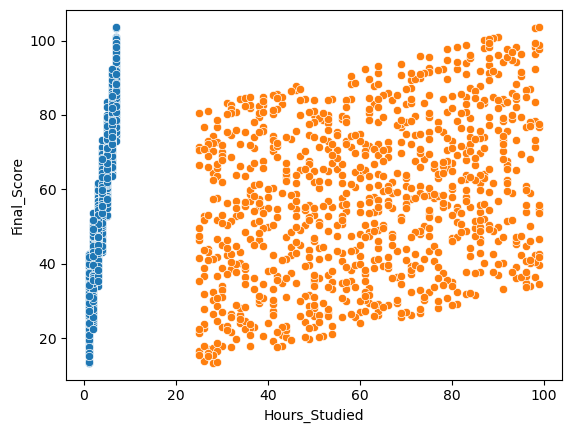

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="Hours_Studied", y="Final_Score", data=df)
sns.scatterplot(x="Attendance", y="Final_Score", data=df)
plt.show()


In [80]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [84]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)


LinearRegression()

In [86]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(x_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R2 Score: 0.9836064608141944
MAE: 2.2581739472165565


In [88]:
new_score = model.predict([[4, 80]])  # 4 hours study, 80% attendance
print("Predicted Score:", new_score[0])


Predicted Score: 63.51309120764085


C:\anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [98]:
import os
import joblib

# Create folder if not exists
os.makedirs("models", exist_ok=True)

# Save model
joblib.dump(model, "models/student_score_model.joblib")
print("Model saved successfully!")


Model saved successfully!


In [100]:
joblib.dump(model, "models/student_score_model.joblib")
print("Model saved as student_score_model.joblib")


Model saved as student_score_model.joblib
